# Notebook 4 — Entrenamiento de Modelo de IA

## Caso: Predicción de Default en Solicitudes de Préstamos

## Objetivo

Entrenar y evaluar un modelo de Machine Learning supervisado que permita predecir si una solicitud de préstamo tiene riesgo de incumplimiento (`loan_status` = 1) a partir de los datos ya limpios y validados por el pipeline (`loans_clean.csv`).

## Etapas

1. Cargar el dataset limpio y validado
2. Análisis de calidad de datos (estadísticas descriptivas, percentiles)
3. Análisis univariado de variables (distribución de la variable objetivo y variables numéricas)
4. Análisis bivariado y matriz de correlación
5. Preprocesamiento: codificación de variables categóricas
6. División en conjuntos de entrenamiento (80%) y prueba (20%)
7. Entrenamiento del modelo (Regresión Logística)
8. Evaluación con métricas: Accuracy, Precision, Recall, F1-Score, Matriz de Confusión, Curva ROC e Indicador Gini
9. Entrenamiento de un segundo modelo (Random Forest) para comparación
10. Conclusión y justificación del modelo elegido

## Paso 1: Importar Librerías

Se importan las librerías necesarias para el análisis exploratorio, preprocesamiento, entrenamiento y evaluación del modelo de Machine Learning.

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## Paso 2: Cargar el Dataset

Se carga `loans_validos.csv`, el dataset final resultante del pipeline (Notebooks 1, 2 y 3), ya pasado por las etapas de ingesta, limpieza y validación.

In [83]:
df = pd.read_csv('../data/processed/loans_validos.csv')

print(f'✅ Dataset cargado correctamente')
print(f'   {df.shape[0]} solicitudes de préstamo  |  {df.shape[1]} variables')
print()
df.head(10)

✅ Dataset cargado correctamente
   44993 solicitudes de préstamo  |  14 variables



,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1
5,21,female,High School,12951,0,OWN,2500,VENTURE,7.14,0.19,2,532,No,1
6,26,female,Bachelor,93471,1,RENT,35000,EDUCATION,12.42,0.37,3,701,No,1
7,24,female,High School,95550,5,RENT,35000,MEDICAL,11.11,0.37,4,585,No,1
8,24,female,Associate,100684,3,RENT,35000,PERSONAL,8.90,0.35,2,544,No,1
9,21,female,High School,12739,0,OWN,1600,VENTURE,14.74,0.13,3,640,No,1


## Paso 3: Análisis de Calidad de Datos

Verificamos la estructura general del dataset, la presencia de valores nulos y las estadísticas descriptivas (media, desviación estándar, percentiles) de las variables numéricas. Como el dataset ya fue procesado por las etapas de limpieza y validación del pipeline, se espera no encontrar valores nulos.

In [84]:
print('📋 Información general:')
print(df.info())
print()
print('🔎 Valores nulos por columna:')
print(df.isnull().sum())
print()
print('📊 Estadísticas descriptivas (variables numéricas):')
df.describe().round(2)

📋 Información general:
<class 'pandas.DataFrame'>
RangeIndex: 44993 entries, 0 to 44992
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44993 non-null  int64  
 1   person_gender                   44993 non-null  str    
 2   person_education                44993 non-null  str    
 3   person_income                   44993 non-null  int64  
 4   person_emp_exp                  44993 non-null  int64  
 5   person_home_ownership           44993 non-null  str    
 6   loan_amnt                       44993 non-null  int64  
 7   loan_intent                     44993 non-null  str    
 8   loan_int_rate                   44993 non-null  float64
 9   loan_percent_income             44993 non-null  float64
 10  cb_person_cred_hist_length      44993 non-null  int64  
 11  credit_score                    44993 non-null  int64  
 12  previous_loan_defaul

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,44993.00,44993.00,44993.00,44993.00,44993.00,44993.00,44993.00,44993.00,44993.00
mean,27.75,79908.45,5.39,9583.18,11.01,0.14,5.87,632.59,0.22
std,5.91,63322.13,5.93,6314.80,2.98,0.09,3.88,50.40,0.42
min,20.00,8000.00,0.00,500.00,5.42,0.00,2.00,390.00,0.00
25%,24.00,47195.00,1.00,5000.00,8.59,0.07,3.00,601.00,0.00
50%,26.00,67046.00,4.00,8000.00,11.01,0.12,4.00,640.00,0.00
75%,30.00,95778.00,8.00,12237.00,12.99,0.19,8.00,670.00,0.00
max,94.00,2448661.00,76.00,35000.00,20.00,0.66,30.00,784.00,1.00


## Paso 4: Análisis Univariado

Se examina la distribución de la variable objetivo (`loan_status`) y de las variables numéricas más relevantes del dataset, con el fin de comprender su comportamiento individual antes de avanzar al modelado.

🎯 Variable objetivo: loan_status
   Sin riesgo / paga (0): 34993 solicitudes (77.8%)
   En riesgo / default (1): 10000 solicitudes (22.2%)


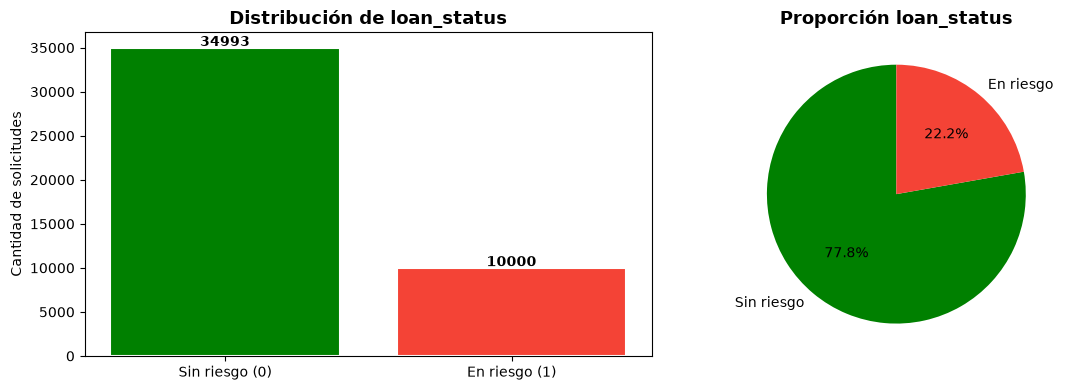

In [85]:
conteo = df['loan_status'].value_counts()
pct    = df['loan_status'].value_counts(normalize=True) * 100

print('🎯 Variable objetivo: loan_status')
print(f'   Sin riesgo / paga (0): {conteo[0]} solicitudes ({pct[0]:.1f}%)')
print(f'   En riesgo / default (1): {conteo[1]} solicitudes ({pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colores = ['green', '#F44336']
axes[0].bar(['Sin riesgo (0)', 'En riesgo (1)'], conteo.values,
            color=colores, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de loan_status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de solicitudes')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold')

axes[1].pie(conteo.values, labels=['Sin riesgo', 'En riesgo'],
            autopct='%1.1f%%', colors=colores, startangle=90)
axes[1].set_title('Proporción loan_status', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Distribución de variables numéricas

Se analiza la distribución de las variables numéricas más relevantes: edad, ingreso anual, score crediticio y tasa de interés del préstamo.

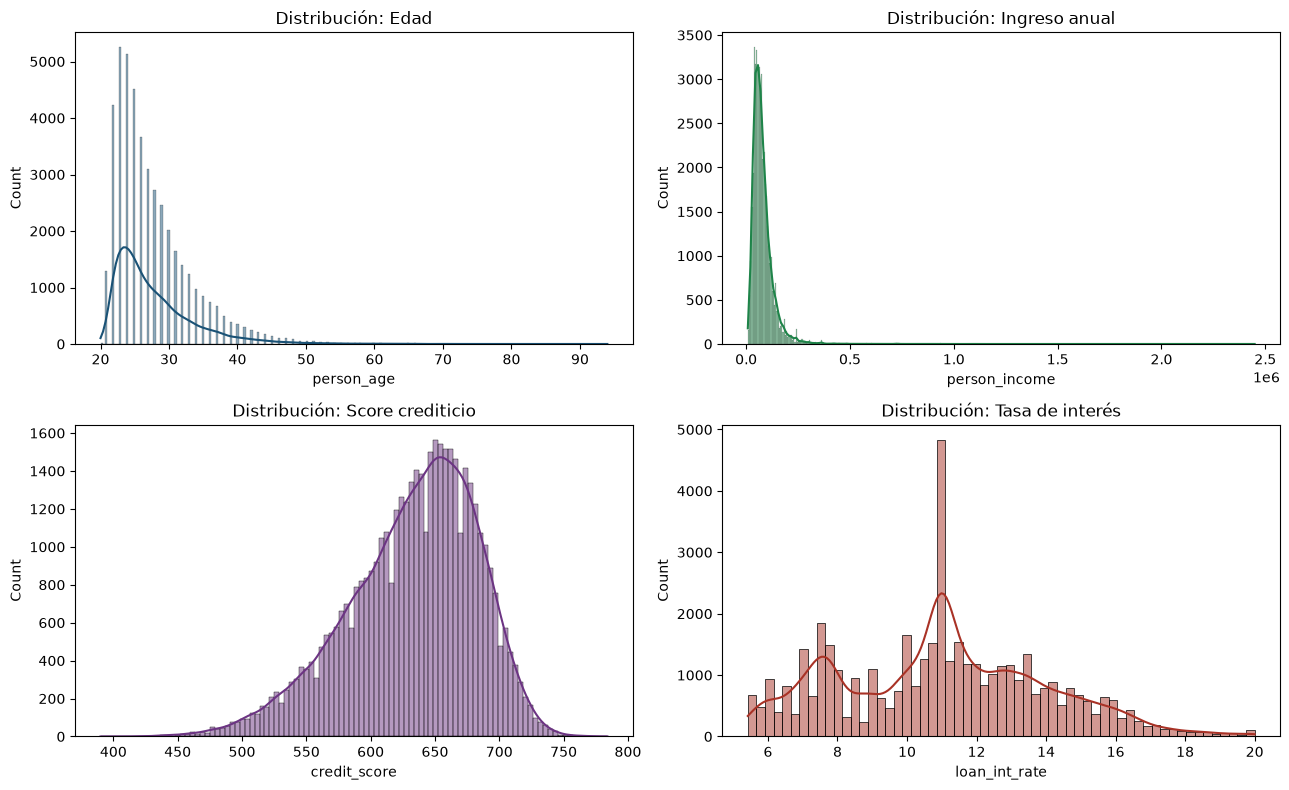

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
sns.histplot(df['person_age'], kde=True, ax=axes[0,0], color='#1A5276')
axes[0,0].set_title('Distribución: Edad')

sns.histplot(df['person_income'], kde=True, ax=axes[0,1], color='#1E8449')
axes[0,1].set_title('Distribución: Ingreso anual')

sns.histplot(df['credit_score'], kde=True, ax=axes[1,0], color='#6C3483')
axes[1,0].set_title('Distribución: Score crediticio')

sns.histplot(df['loan_int_rate'], kde=True, ax=axes[1,1], color='#A93226')
axes[1,1].set_title('Distribución: Tasa de interés')

plt.tight_layout()
plt.show()

## Paso 5: Análisis Bivariado y Matriz de Correlación

Se analiza la relación entre variables predictoras clave y la variable objetivo (`loan_status`), además de calcular la matriz de correlación entre las variables numéricas del dataset.

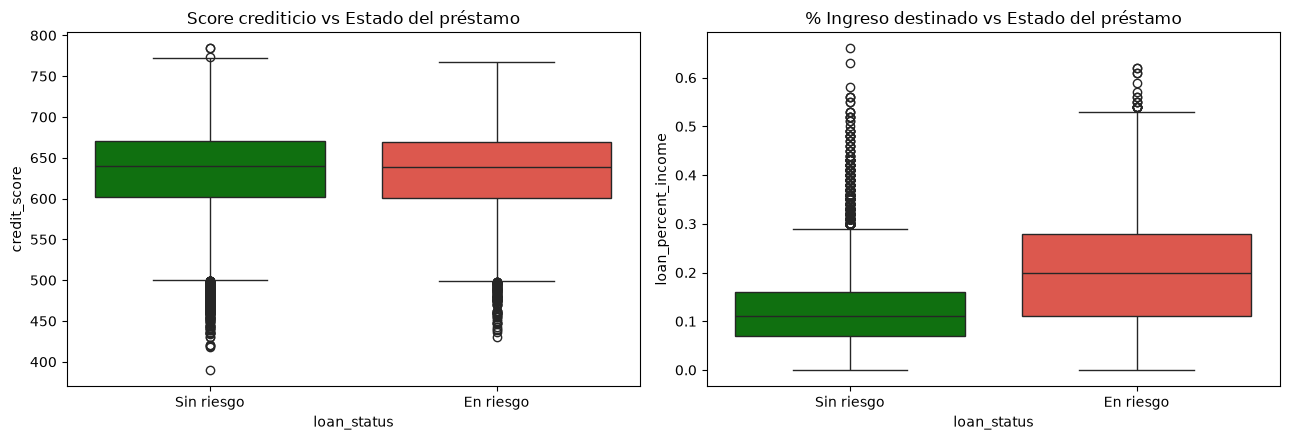

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(x='loan_status', y='credit_score', data=df, ax=axes[0], palette=['green','#F44336'])
axes[0].set_title('Score crediticio vs Estado del préstamo')
axes[0].set_xticklabels(['Sin riesgo', 'En riesgo'])

sns.boxplot(x='loan_status', y='loan_percent_income', data=df, ax=axes[1], palette=['green','#F44336'])
axes[1].set_title('% Ingreso destinado vs Estado del préstamo')
axes[1].set_xticklabels(['Sin riesgo', 'En riesgo'])

plt.tight_layout()
plt.show()

### Matriz de Correlación

Se calcula la correlación entre las variables numéricas para identificar relaciones lineales con la variable objetivo y entre sí.

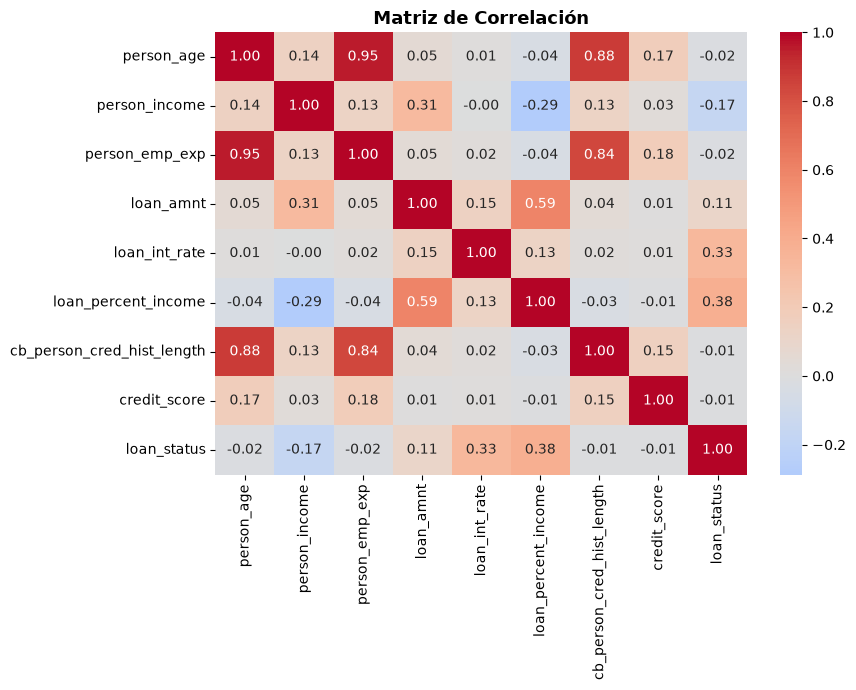

🔎 Correlaciones más relevantes con loan_status:
loan_status                   1.000000
loan_percent_income           0.384873
loan_int_rate                 0.332046
loan_amnt                     0.107725
credit_score                 -0.007409
cb_person_cred_hist_length   -0.014733
person_emp_exp               -0.019529
person_age                   -0.020545
person_income                -0.169034
Name: loan_status, dtype: float64


In [88]:
num_cols = ['person_age','person_income','person_emp_exp','loan_amnt',
            'loan_int_rate','loan_percent_income','cb_person_cred_hist_length',
            'credit_score','loan_status']

plt.figure(figsize=(9,7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de Correlación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('🔎 Correlaciones más relevantes con loan_status:')
print(corr['loan_status'].sort_values(ascending=False))

## Paso 6: Preprocesamiento — Codificación de Variables Categóricas

El dataset contiene variables categóricas que deben convertirse a formato numérico para que el modelo pueda procesarlas:

- **Variables binarias** (`person_gender`, `previous_loan_defaults_on_file`) → codificación 0/1
- **Variable ordinal** (`person_education`) → mapeo según orden lógico de nivel educativo
- **Variables nominales** (`person_home_ownership`, `loan_intent`) → One-Hot Encoding

In [89]:
df_enc = df.copy()

# Variables binarias
df_enc['person_gender'] = df_enc['person_gender'].map({'male': 1, 'female': 0})
df_enc['previous_loan_defaults_on_file'] = df_enc['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0})

# Variable ordinal: educación
orden_educacion = {'High School': 0, 'Associate': 1, 'Bachelor': 2, 'Master': 3, 'Doctorate': 4}
df_enc['person_education'] = df_enc['person_education'].map(orden_educacion)

# Variables nominales: One-Hot Encoding
df_enc = pd.get_dummies(df_enc, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

print('✅ Codificación completada')
print(f'   Columnas finales: {df_enc.shape[1]}')
df_enc.head()

✅ Codificación completada
   Columnas finales: 20


,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,0,3,71948,0,35000,16.02,0.49,3,561,0,1,False,False,True,False,False,False,True,False
1,21,0,0,12282,0,1000,11.14,0.08,2,504,1,0,False,True,False,True,False,False,False,False
2,25,0,0,12438,3,5500,12.87,0.44,3,635,0,1,False,False,False,False,False,True,False,False
3,23,0,2,79753,0,35000,15.23,0.44,2,675,0,1,False,False,True,False,False,True,False,False
4,24,1,3,66135,1,35000,14.27,0.53,4,586,0,1,False,False,True,False,False,True,False,False


## Paso 7: Seleccionar Variables

**Variable objetivo (y):** `loan_status`
**Variables predictoras (X):** todas las demás columnas, ya codificadas

In [90]:
X = df_enc.drop(columns=['loan_status'])
y = df_enc['loan_status']

print('✅ Variables seleccionadas:')
print(f'   Variables predictoras (X): {list(X.columns)}')
print(f'   Variable objetivo    (y) : loan_status')
print()
print(f'   Dimensiones de X: {X.shape}')
print(f'   Dimensiones de y: {y.shape}')

✅ Variables seleccionadas:
   Variables predictoras (X): ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']
   Variable objetivo    (y) : loan_status

   Dimensiones de X: (44993, 19)
   Dimensiones de y: (44993,)


## Paso 8: Dividir en Entrenamiento y Prueba

Se divide el dataset en un 80% para entrenamiento y un 20% para prueba, utilizando `stratify=y` para mantener la misma proporción de riesgo (22%) en ambos conjuntos.

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('✅ División completada:')
print(f'   Total de registros : {len(df_enc)}')
print(f'   Entrenamiento      : {len(X_train)} registros ({len(X_train)/len(df_enc)*100:.0f}%)')
print(f'   Prueba             : {len(X_test)}  registros ({len(X_test)/len(df_enc)*100:.0f}%)')
print()
print('🔎 Balance de clases por conjunto:')
print(f'   Entrenamiento → En riesgo: {y_train.mean()*100:.1f}%')
print(f'   Prueba        → En riesgo: {y_test.mean()*100:.1f}%')

✅ División completada:
   Total de registros : 44993
   Entrenamiento      : 35994 registros (80%)
   Prueba             : 8999  registros (20%)

🔎 Balance de clases por conjunto:
   Entrenamiento → En riesgo: 22.2%
   Prueba        → En riesgo: 22.2%


## Paso 9: Entrenar el Modelo (Regresión Logística)

Se utiliza Regresión Logística como modelo base por su interpretabilidad, característica relevante en el contexto bancario donde se debe justificar la decisión de aprobar o rechazar un préstamo. Como este algoritmo es sensible a la escala de los datos, se aplica `StandardScaler` para normalizar las variables numéricas antes de entrenar.

In [92]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo = LogisticRegression(penalty='l2', max_iter=500, random_state=42)
modelo.fit(X_train_scaled, y_train)

print('✅ ¡Modelo entrenado exitosamente!')
print()
coeficientes = pd.DataFrame({
    'Variable'    : X.columns,
    'Coeficiente' : modelo.coef_[0].round(4)
}).sort_values('Coeficiente', ascending=False)
print('📐 Variables con mayor influencia en el riesgo:')
print(coeficientes.to_string(index=False))

✅ ¡Modelo entrenado exitosamente!

📐 Variables con mayor influencia en el riesgo:
                      Variable  Coeficiente
           loan_percent_income       1.4216
                 loan_int_rate       0.9944
    person_home_ownership_RENT       0.3761
                 person_income       0.1301
                    person_age       0.1143
   person_home_ownership_OTHER       0.0267
                 person_gender       0.0187
              person_education       0.0050
   loan_intent_HOMEIMPROVEMENT      -0.0068
    cb_person_cred_hist_length      -0.0336
                person_emp_exp      -0.0750
           loan_intent_MEDICAL      -0.1062
          loan_intent_PERSONAL      -0.2740
     person_home_ownership_OWN      -0.3413
         loan_intent_EDUCATION      -0.3779
                  credit_score      -0.4578
           loan_intent_VENTURE      -0.4785
                     loan_amnt      -0.6737
previous_loan_defaults_on_file      -4.5285


## Paso 10: Evaluar el Modelo

Se calculan las métricas de evaluación exigidas: Accuracy, Precision, Recall, F1-Score, Matriz de Confusión, Curva ROC y el Coeficiente de Gini, fundamentales para medir el rendimiento de un modelo de scoring crediticio.

In [93]:
y_pred = modelo.predict(X_test_scaled)
y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_proba)
gini      = 2 * auc - 1

print('📊 MÉTRICAS DE EVALUACIÓN — Regresión Logística')
print('=' * 45)
print(f'  Accuracy  (Exactitud) : {accuracy*100:.1f}%')
print(f'  Precision             : {precision*100:.1f}%')
print(f'  Recall (Sensibilidad) : {recall*100:.1f}%')
print(f'  F1-Score              : {f1*100:.1f}%')
print(f'  AUC (curva ROC)       : {auc:.3f}')
print(f'  Coeficiente de Gini   : {gini:.3f}')
print('=' * 45)

📊 MÉTRICAS DE EVALUACIÓN — Regresión Logística
  Accuracy  (Exactitud) : 89.5%
  Precision             : 77.2%
  Recall (Sensibilidad) : 74.8%
  F1-Score              : 76.0%
  AUC (curva ROC)       : 0.952
  Coeficiente de Gini   : 0.905


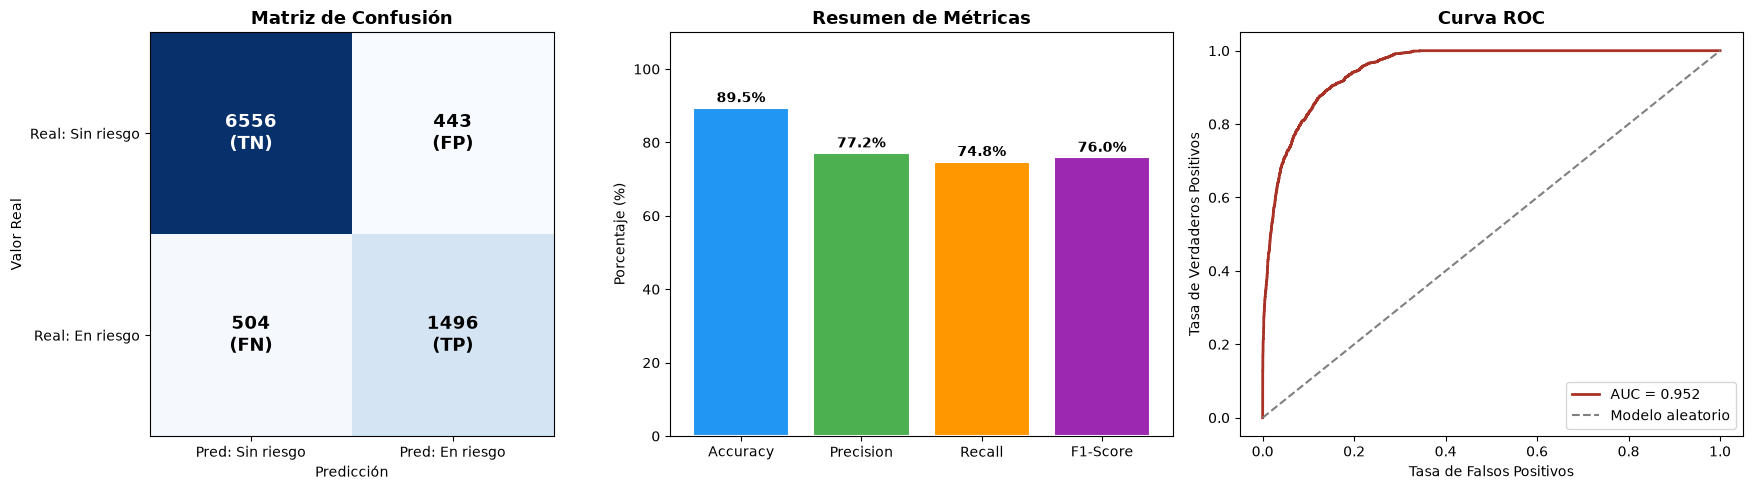


📋 Reporte completo:
              precision    recall  f1-score   support

  Sin riesgo       0.93      0.94      0.93      6999
   En riesgo       0.77      0.75      0.76      2000

    accuracy                           0.89      8999
   macro avg       0.85      0.84      0.85      8999
weighted avg       0.89      0.89      0.89      8999



In [94]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión
axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred: Sin riesgo', 'Pred: En riesgo'])
axes[0].set_yticklabels(['Real: Sin riesgo', 'Real: En riesgo'])
axes[0].set_ylabel('Valor Real'); axes[0].set_xlabel('Predicción')
etiquetas = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i, j]}\n({etiquetas[i][j]})',
                     ha='center', va='center', fontsize=13, fontweight='bold',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

# Barras de métricas
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores = [accuracy, precision, recall, f1]
colores_m = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = axes[1].bar(metricas_nombres, [v*100 for v in valores], color=colores_m, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 110); axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Resumen de Métricas', fontsize=13, fontweight='bold')
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=10)

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, color='#A93226', linewidth=2, label=f'AUC = {auc:.3f}')
axes[2].plot([0,1],[0,1], linestyle='--', color='gray', label='Modelo aleatorio')
axes[2].set_xlabel('Tasa de Falsos Positivos')
axes[2].set_ylabel('Tasa de Verdaderos Positivos')
axes[2].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

print()
print('📋 Reporte completo:')
print(classification_report(y_test, y_pred, target_names=['Sin riesgo', 'En riesgo']))

## Paso 11: Comparar con Random Forest

Se entrena un segundo modelo, Random Forest, para evaluar si un algoritmo más complejo mejora la capacidad de detectar el riesgo real. A diferencia de la Regresión Logística, Random Forest no requiere escalado de variables.

In [95]:
rf = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_proba_rf)
gini_rf = 2 * auc_rf - 1

print('📊 COMPARACIÓN DE ALGORITMOS')
print('=' * 65)
print(f'{"Métrica":<22} {"Reg. Logística":>18} {"Random Forest":>18}')
print('-' * 65)

metricas_comp = {
    'Accuracy' : (accuracy, accuracy_score(y_test, y_pred_rf)),
    'Precision': (precision, precision_score(y_test, y_pred_rf)),
    'Recall'   : (recall, recall_score(y_test, y_pred_rf)),
    'F1-Score' : (f1, f1_score(y_test, y_pred_rf)),
    'AUC'      : (auc, auc_rf),
    'Gini'     : (gini, gini_rf),
}

for nombre, (v1, v2) in metricas_comp.items():
    mejor1 = '👑' if v1 >= v2 else '  '
    mejor2 = '👑' if v2 > v1 else '  '
    print(f'{nombre:<22} {mejor1}{v1*100:>14.1f}%   {mejor2}{v2*100:>14.1f}%')

print('=' * 65)

📊 COMPARACIÓN DE ALGORITMOS
Métrica                    Reg. Logística      Random Forest
-----------------------------------------------------------------
Accuracy                           89.5%   👑          92.1%
Precision                          77.2%   👑          91.5%
Recall                 👑          74.8%               71.0%
F1-Score                           76.0%   👑          79.9%
AUC                                95.2%   👑          96.9%
Gini                               90.5%   👑          93.8%


### Importancia de Variables (Random Forest)

Se identifican las variables que más influyen en las predicciones del modelo Random Forest.

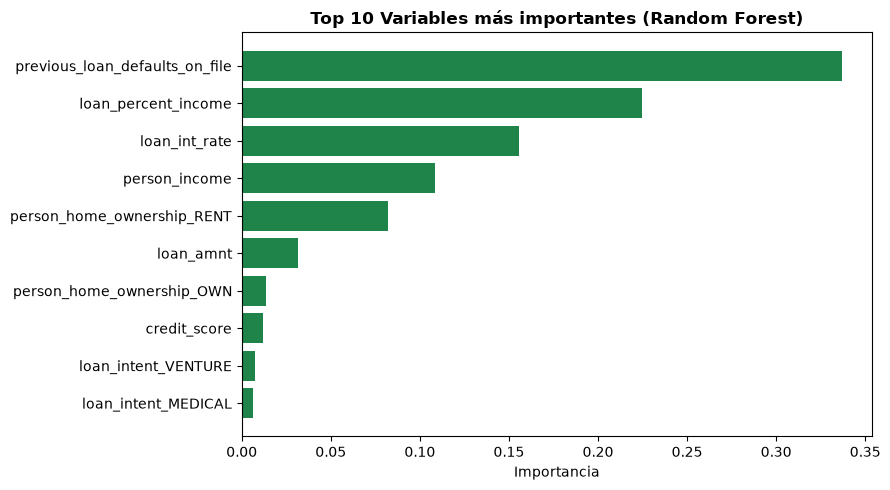

In [96]:
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False).head(10)

plt.figure(figsize=(9,5))
plt.barh(importancias['Variable'], importancias['Importancia'], color='#1E8449')
plt.title('Top 10 Variables más importantes (Random Forest)', fontsize=12, fontweight='bold')
plt.xlabel('Importancia')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Guardar el modelo entrenado (joblib)

In [97]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(rf, "../models/random_forest_modelo.joblib")
joblib.dump(modelo, "../models/regresion_logistica_modelo.joblib")
joblib.dump(scaler, "../models/scaler.joblib")

print("Modelos guardados en /models")

Modelos guardados en /models


Crear el log de entrenamiento (mismo estilo que los otros 3)

In [ ]:
import logging
from datetime import datetime
import os
import logging


for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

log_path = 'data/logs/training.log' 
if os.path.exists(log_path):
    with open(log_path, 'w'): pass


logging.basicConfig(
    filename='../logs/training.log',
    level=logging.INFO,
    filemode='w',
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
    
)

logger = logging.getLogger()

logger.info("Inicio del proceso de entrenamiento del modelo - Pipeline DataOps")
logger.info(f"Dataset de entrada: loans_validos.csv - {len(df)} registros")
logger.info(f"Partición train/test: {len(X_train)} entrenamiento / {len(X_test)} prueba (80/20, stratify=y)")
logger.info("Modelo 1: Regresión Logística (penalty='l2', max_iter=500)")
logger.info(f"Métricas LR - Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | Gini: {gini:.4f}")
logger.info("Modelo 2: Random Forest (n_estimators=150, max_depth=8)")
logger.info(f"Métricas RF - Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} | Precision: {precision_score(y_test, y_pred_rf):.4f} | Recall: {recall_score(y_test, y_pred_rf):.4f} | F1: {f1_score(y_test, y_pred_rf):.4f} | AUC: {auc_rf:.4f} | Gini: {gini_rf:.4f}")
logger.info("Modelo seleccionado: Random Forest (mejor AUC y Gini)")
logger.info("Modelos exportados: random_forest_modelo.joblib, regresion_logistica_modelo.joblib, scaler.joblib")
logger.info("Fin del proceso de entrenamiento - Modelo listo para inferencia")

print("Log de entrenamiento generado en logs/training.log")

Log de entrenamiento generado en logs/training.log


## Paso 12: Conclusión y Justificación del Modelo

El modelo Random Forest obtuvo mejor desempeño general (Accuracy 92.1%, AUC 0.969, Gini 0.938) en comparación con la Regresión Logística (Accuracy 89.5%, AUC 0.952, Gini 0.905), aunque esta última mostró un recall levemente superior (74.8% vs 71.0%).

**Justificación:** se elige Random Forest como modelo principal porque logra mejor capacidad de discriminación general entre clientes riesgosos y no riesgosos, al capturar relaciones no lineales entre variables que la Regresión Logística no detecta. Sin embargo, se reconoce el valor de la Regresión Logística como modelo de respaldo por su mayor interpretabilidad, relevante en el contexto bancario donde se debe justificar la aprobación o rechazo de un préstamo.

Ambos modelos coincidieron en que `previous_loan_defaults_on_file`, `loan_percent_income` y `loan_int_rate` son las variables más influyentes en la predicción del riesgo, lo que valida la coherencia del análisis. Por otro lado, `credit_score` mostró baja relevancia en ambos modelos, resultado inesperado que vale la pena seguir explorando.